Importing Libraries and Setting Up the Environment

In [1]:
import numpy as np
import pandas as pd 

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


Collecting Historical Gold Price Data

In [2]:
stocks = input("Enter the code of the stock:- ")
# Download historical Gold Futures data
data = yf.download(
    stocks,
    "2010-01-01",
    "2026-01-01",
    auto_adjust=True
)

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2010-01-04,23.027510,23.139113,22.759661,22.781982,38409100
2010-01-05,23.034948,23.139113,22.796861,22.953107,49749600
2010-01-06,22.893581,23.124228,22.707576,22.975423,58182400
2010-01-07,22.655495,22.841500,22.462049,22.789418,50559700
2010-01-08,22.811739,22.975423,22.499249,22.529011,51197400


In [3]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   4024 non-null   float64
 1   (High, MSFT)    4024 non-null   float64
 2   (Low, MSFT)     4024 non-null   float64
 3   (Open, MSFT)    4024 non-null   float64
 4   (Volume, MSFT)  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB


In [4]:
data.shape

(4024, 5)

In [6]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,4024.000000,4024.000000,4024.000000,4024.000000,4.024000e+03
mean,148.970839,150.312708,147.495745,148.937757,3.529555e+07
std,144.805884,146.037538,143.470607,144.808001,2.058245e+07
min,17.277636,17.510408,17.067392,17.337707,5.855900e+06
25%,30.700635,30.958771,30.432386,30.727487,2.192250e+07
50%,78.644955,79.139422,78.136796,78.896761,2.938710e+07
75%,250.276699,252.593478,246.741298,249.776658,4.318792e+07
max,538.658569,551.048474,537.366763,550.830186,3.193179e+08


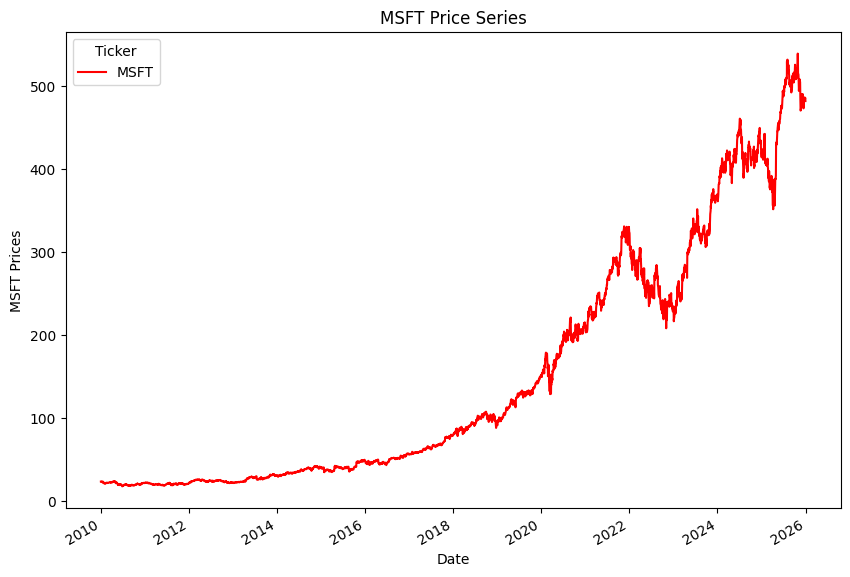

In [7]:
data.Close.plot(figsize=(10, 7), color='r')
plt.ylabel("{} Prices".format(stocks))
plt.title("{} Price Series".format(stocks))
plt.show()


<Axes: ylabel='Count'>

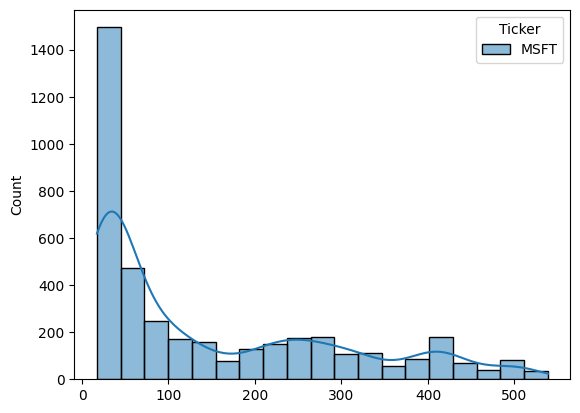

In [8]:
sns.histplot(data["Close"], kde=True)


<Axes: ylabel='Count'>

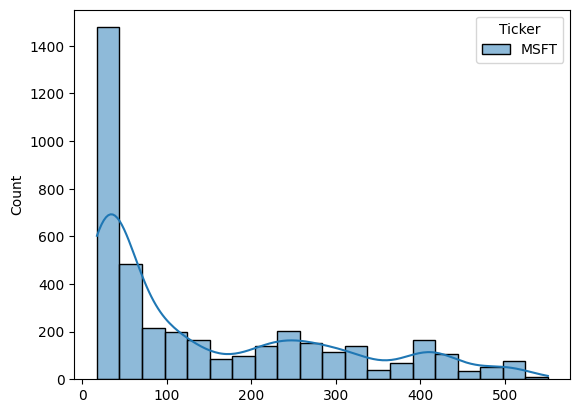

In [9]:
sns.histplot(data["Open"], kde=True)


<Axes: ylabel='Count'>

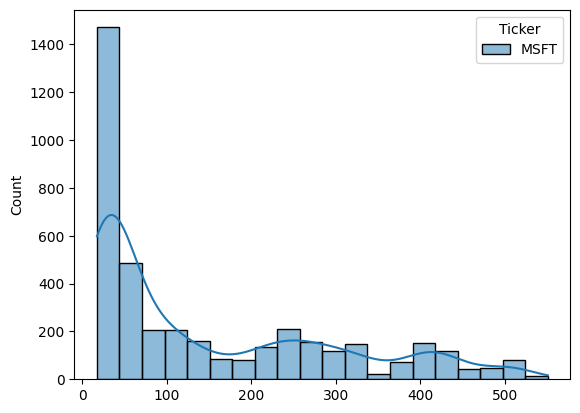

In [10]:
sns.histplot(data["High"], kde=True)

In [11]:
x = data.drop("Close" , axis = 1)
y = data["Close"]

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3219, 4)
(805, 4)
(3219, 1)
(805, 1)


In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
pred1 = lr.predict(x_test)


In [13]:
pred1

array([[ 48.46654362],
       [165.72768566],
       [ 25.43898197],
       [ 67.70873603],
       [ 21.61907886],
       [ 47.96789379],
       [105.97293873],
       [ 76.36955442],
       [161.50904181],
       [323.62761316],
       [106.23836304],
       [411.25250506],
       [ 62.31105603],
       [365.19394177],
       [419.92558068],
       [ 19.49149311],
       [ 34.96508969],
       [129.65136497],
       [ 21.57273821],
       [131.32406005],
       [145.83519618],
       [ 54.33298168],
       [ 54.2061641 ],
       [479.0608345 ],
       [289.67699271],
       [ 33.35192674],
       [ 87.16988001],
       [ 58.6710161 ],
       [ 30.29675034],
       [124.97109414],
       [323.94013962],
       [247.99014909],
       [131.08707407],
       [ 18.81206184],
       [ 33.64276503],
       [ 25.01449566],
       [298.81060781],
       [173.40658095],
       [475.77183675],
       [ 39.24143446],
       [ 21.97046149],
       [ 65.01010419],
       [402.84686955],
       [ 58

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

def calculate_metrics(y_test, y_pred):
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_scors = r2_score(y_test, y_pred)

    print("MSE:- ", mse)
    print("RMSE:- ", rmse)
    print("R2_score:- ", r2_scors)

calculate_metrics(y_test, pred1)


MSE:-  2.8507157365159537
RMSE:-  1.6884062711669705
R2_score:-  0.9998692855374793


In [15]:
from sklearn.linear_model import Lasso , Ridge

la = Lasso().fit(x_train , y_train)
ri = Ridge().fit(x_train , y_train)

la_p = la.predict(x_test)
ri_p = ri.predict(x_test)


In [16]:
calculate_metrics(y_test , la_p)

MSE:-  2.7901720510981978
RMSE:-  1.6703808102041275
R2_score:-  0.9998720616596991


In [17]:
calculate_metrics(y_test ,ri_p)

MSE:-  0.9331786952696193
RMSE:-  0.9660117469625404
R2_score:-  0.9999572107628882


In [18]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR()
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(svr, param_grid, refit=True, verbose=3)
grid.fit(x_train , y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.262 total time=   0.2s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.149 total time=   0.2s


...

[CV 4/5] END ..C=1000, gamma=0.0001, kernel=rbf;, score=0.003 total time=   0.4s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END ..C=1000, gamma=0.0001, kernel=rbf;, score=0.001 total time=   0.4s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is u

In [19]:
svr = SVR(C=1000, gamma=0.0001, kernel='rbf') 

svr.fit(x_train, y_train)

svr_pred = svr.predict(x_test)

c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [20]:
calculate_metrics(y_test, svr_pred)

MSE:-  21750.70609943815
RMSE:-  147.48120591939215
R2_score:-  0.002660342167818186


In [22]:
import joblib

joblib.dump(ri, "microsoft_model.pkl")

ridge_from_joblib = model = joblib.load("microsoft_model.pkl")

In [23]:
model = joblib.load("microsoft_model.pkl")

In [24]:
prediction = model.predict(x_test)

print(prediction[:5])

[ 48.50553833 166.52140944  25.53894036  67.7607457   21.7872107 ]


In [25]:
print("Predicted:", prediction[:5])
print("Actual:   ", y_test[:5].values)

Predicted: [ 48.50553833 166.52140944  25.53894036  67.7607457   21.7872107 ]
Actual:    [[ 48.63373566]
 [167.80795288]
 [ 25.56130028]
 [ 68.04798889]
 [ 21.63270569]]
